# NB-B2: Ensemble Fusion & Confidence Calibration


## The Consensus Layer
This notebook represents the "Brain" of the PulseMind system. It synthesizes insights from our three innovation vectors:
1. **Morphological (A1)**: Detailed QRS/P-wave shape analysis.
2. **Temporal (A2)**: Rhythm and RR-interval trend analysis.
3. **Attention (B1)**: Long-range global dependencies between beats.

## Clinical Pacing Gate
The system uses **Uncertainty-Gated Pacing**. If the models disagree too much, the system enters `SQI_INHIBITED` mode to prevent patient risk.

###  Setting the Stage: The Consensus Engine
This is where all the previous research comes together. I'm building a 'Consensus Engine' that listens to the ResNet, the BiGRU, and the CardioFormer. I'm importing the usual dependencies and setting up my CUDA environment to handle multiple models simultaneously.

In [1]:
# Cell 1: Unified Dependencies
import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.metrics import classification_report, f1_score
import wfdb, math, os

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"PulseMind Consensus Engine running on: {device}")


PulseMind Consensus Engine running on: cuda


###  Synchronizing the Brains: Model Definitions
In this cell, I'm redefining all three architectures (ResNet, BiGRU, and CardioFormer) so they are perfectly synchronized. It's crucial that these definitions match exactly what was used during individual training, as I'll be loading those pre-trained weights shortly.

In [2]:
# Cell 2: All Model Architectures (EXACT CLINICAL DEFINITIONS)

# --- 1. Multi-Scale ResNet Architecture (NB-A1) ---
class SEBlock1D(nn.Module):
    def __init__(self, channels, reduction=8):
        super().__init__()
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc   = nn.Sequential(
            nn.Linear(channels, channels // reduction, bias=False),
            nn.ReLU(),
            nn.Linear(channels // reduction, channels, bias=False),
            nn.Sigmoid())
    def forward(self, x):
        b, c, _ = x.shape
        scale = self.pool(x).view(b, c)
        scale = self.fc(scale).view(b, c, 1)
        return x * scale

class ResBlock1D(nn.Module):
    def __init__(self, in_ch, out_ch, kernel=3, stride=1):
        super().__init__()
        pad = kernel // 2
        self.conv1 = nn.Sequential(
            nn.Conv1d(in_ch, out_ch, kernel, stride=stride, padding=pad, bias=False),
            nn.BatchNorm1d(out_ch), nn.ReLU())
        self.conv2 = nn.Sequential(
            nn.Conv1d(out_ch, out_ch, kernel, stride=1, padding=pad, bias=False),
            nn.BatchNorm1d(out_ch))
        self.se = SEBlock1D(out_ch)
        self.relu = nn.ReLU()
        self.downsample = (
            nn.Sequential(nn.Conv1d(in_ch, out_ch, 1, stride=stride, bias=False), nn.BatchNorm1d(out_ch))
            if stride != 1 or in_ch != out_ch else nn.Identity())
    def forward(self, x):
        return self.relu(self.se(self.conv2(self.conv1(x))) + self.downsample(x))

class MultiScaleBranch(nn.Module):
    def __init__(self, kernel_size, out_ch=32):
        super().__init__()
        self.branch = nn.Sequential(
            nn.Conv1d(1, out_ch, kernel_size=kernel_size, padding=kernel_size//2, bias=False),
            nn.BatchNorm1d(out_ch), nn.ReLU(),
            ResBlock1D(out_ch, out_ch * 2, stride=2),
            ResBlock1D(out_ch * 2, out_ch * 2),
            nn.AdaptiveAvgPool1d(1))
    def forward(self, x): return self.branch(x)

class MultiScaleResNet(nn.Module):
    def __init__(self, num_classes=4, branch_ch=32):
        super().__init__()
        self.branch_fine   = MultiScaleBranch(kernel_size=5,  out_ch=branch_ch)
        self.branch_mid    = MultiScaleBranch(kernel_size=11, out_ch=branch_ch)
        self.branch_coarse = MultiScaleBranch(kernel_size=21, out_ch=branch_ch)
        fused_ch = branch_ch * 2 * 3
        self.se_fusion = SEBlock1D(fused_ch)
        self.classifier = nn.Sequential(
            nn.Flatten(), nn.Linear(fused_ch, 256), nn.ReLU(), nn.Dropout(0.4), nn.Linear(256, num_classes))
    def forward(self, x):
        f = torch.cat([self.branch_fine(x), self.branch_mid(x), self.branch_coarse(x)], dim=1)
        f = self.se_fusion(f)
        return self.classifier(f)

# --- 2. BiGRU Architecture (NB-A2) ---
class TemporalAttention(nn.Module):
    def __init__(self, embed_dim, num_heads=4):
        super().__init__()
        self.attn = nn.MultiheadAttention(embed_dim, num_heads, dropout=0.1, batch_first=True)
        self.norm = nn.LayerNorm(embed_dim)
    def forward(self, x):
        attn_out, _ = self.attn(x, x, x)
        return self.norm(x + attn_out)

class BiGRU_TemporalModel(nn.Module):
    def __init__(self, window_size=300, hidden_size=128, num_classes=4):
        super().__init__()
        # MATCH SAVED WEIGHT KEYS: enc.net, gru, attn, head
        self.enc = nn.ModuleDict({
            "net": nn.Sequential(
                nn.Conv1d(1, 16, 7, padding=3), nn.ReLU(), nn.MaxPool1d(4),
                nn.Conv1d(16, 32, 5, padding=2), nn.ReLU(), nn.MaxPool1d(4), nn.Flatten(),
                nn.Linear(32 * (window_size // 16), hidden_size))
        })
        self.gru = nn.GRU(hidden_size, hidden_size, num_layers=2, batch_first=True, bidirectional=True, dropout=0.3)
        self.attn = TemporalAttention(embed_dim=hidden_size * 2)
        self.head = nn.Sequential(nn.Linear(hidden_size * 2, 64), nn.ReLU(), nn.Dropout(0.4), nn.Linear(64, num_classes))
    def forward(self, x):
        b, s, w = x.shape
        e_out = self.enc["net"](x.view(b*s, 1, w)).view(b, s, -1)
        g_out, _ = self.gru(e_out)
        at_out = self.attn(g_out)
        return self.head(at_out.mean(dim=1))

# --- 3. CardioFormer Architecture (NB-B1) ---
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=50):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        dt = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * dt)
        pe[:, 1::2] = torch.cos(pos * dt)
        self.register_buffer('pe', pe)
    def forward(self, x): return x + self.pe[:x.size(1), :]

class CardioFormer(nn.Module):
    def __init__(self, d_model=128, nhead=8, num_layers=4, num_classes=4):
        super().__init__()
        self.tokenizer = nn.Sequential(
            nn.Conv1d(1, 16, 7, padding=3), nn.ReLU(), nn.MaxPool1d(4),
            nn.Conv1d(16, 32, 5, padding=2), nn.ReLU(), nn.MaxPool1d(4), nn.Flatten(),
            nn.Linear(32 * (300 // 16), d_model))
        self.pos_encoder = PositionalEncoding(d_model)
        el = nn.TransformerEncoderLayer(d_model, nhead, dim_feedforward=512, dropout=0.2, batch_first=True)
        self.transformer = nn.TransformerEncoder(el, num_layers=num_layers)
        self.classifier = nn.Sequential(nn.Linear(d_model, 64), nn.ReLU(), nn.Dropout(0.3), nn.Linear(64, num_classes))
    def forward(self, x):
        b, s, w = x.shape
        t = self.tokenizer(x.view(b*s, 1, w)).view(b, s, -1)
        t = self.pos_encoder(t)
        out = self.transformer(t)
        return self.classifier(out.mean(dim=1))

print("Model Architectures Synchronized.")

Model Architectures Synchronized.


###  Loading Synchronized Data
I'm setting up a special data loader that provides both single heartbeats (for the ResNet) and 8-beat sequences (for the BiGRU and CardioFormer) at the same time. This 'Synchronized' loader ensures that all three models are looking at the exact same clinical event when making their predictions.

In [3]:
# Cell 3: Synchronized Data Loading
TEST_RECORDS = ['200', '201']
CLASS_NAMES  = ['Normal (N)', 'LBBB (L)', 'RBBB (R)', 'PVC (V)']

def load_synchronized_test(record_ids, window_size=300, seq_len=8):
    X_morph, X_seq, y_eval = [], [], []
    for rid in record_ids:
        record = wfdb.rdrecord(rid, pn_dir='mitdb'); ann = wfdb.rdann(rid, 'atr', pn_dir='mitdb')
        sig = record.p_signal[:, 0]
        beats, labels = [], []
        for i, pk in enumerate(ann.sample):
            if ann.symbol[i] in {'N', 'L', 'R', 'V'} and pk > window_size//2 and pk < len(sig)-window_size//2:
                beats.append(sig[pk-window_size//2:pk+window_size//2])
                labels.append({'N':0, 'L':1, 'R':2, 'V':3}[ann.symbol[i]])
        for i in range(len(beats) - seq_len):
            X_seq.append(beats[i : i + seq_len])
            X_morph.append(beats[i + seq_len - 1]) # Last beat for ResNet
            y_eval.append(labels[i + seq_len - 1])
    return torch.FloatTensor(np.array(X_morph)), torch.FloatTensor(np.array(X_seq)), torch.LongTensor(np.array(y_eval))

Xm, Xq, y = load_synchronized_test(TEST_RECORDS)
test_loader = DataLoader(TensorDataset(Xm, Xq, y), batch_size=32)
print(f"Synchronized Test Set: {len(y)} samples across {len(TEST_RECORDS)} patients.")

Synchronized Test Set: 4375 samples across 2 patients.


### The Ensemble Vote: Combined Performance
Now for the exciting part—the ensemble! I'm loading the pre-trained weights for all models and letting them 'vote' on the classification. By averaging their predictions, I'm aiming for a consensus that is more accurate and robust than any single model alone. Check out the improved metrics!

In [4]:
# Cell 4: Consensus Engine (Soft-Voting + Uncertainty)
m1 = MultiScaleResNet().to(device); m1.load_state_dict(torch.load('../ai_training/output/NB_A1_MultiScaleResNet.pth', map_location=device, weights_only=True))
m2 = BiGRU_TemporalModel().to(device); m2.load_state_dict(torch.load('../ai_training/output/NB_A2_BiGRU_Temporal.pth', map_location=device, weights_only=True))
m3 = CardioFormer().to(device); m3.load_state_dict(torch.load('../ai_training/output/NB_B1_CardioFormer.pth', map_location=device, weights_only=True))

m1.eval(); m2.eval(); m3.eval()
all_preds, all_labels, all_uncert = [], [], []

with torch.no_grad():
    for bx_m, bx_q, by in test_loader:
        p1 = torch.softmax(m1(bx_m.unsqueeze(1).to(device)), dim=1)
        p2 = torch.softmax(m2(bx_q.to(device)), dim=1)
        p3 = torch.softmax(m3(bx_q.to(device)), dim=1)
        consensus_prob = (p1 + p2 + p3) / 3
        disagreement = torch.stack([p1, p2, p3]).std(dim=0).mean(dim=1)
        all_preds.extend(consensus_prob.argmax(1).cpu().numpy())
        all_labels.extend(by.numpy())
        all_uncert.extend(disagreement.cpu().numpy())

preds, labels, uncertainty = np.array(all_preds), np.array(all_labels), np.array(all_uncert)

print("="*60)
print("  PulseMind Ensemble Fusion Center | Inter-Patient Report")
print(f"  Final Accuracy: {(preds==labels).mean()*100:.2f}%")
print(f"  Mean Uncertainty: {uncertainty.mean():.4f}")
print("="*60)
pcls = np.unique(labels)
pnames = [CLASS_NAMES[i] for i in pcls]
print(classification_report(labels, preds, labels=pcls, target_names=pnames, zero_division=0))

  PulseMind Ensemble Fusion Center | Inter-Patient Report
  Final Accuracy: 98.22%
  Mean Uncertainty: 0.0359
              precision    recall  f1-score   support

  Normal (N)       0.98      1.00      0.99      3355
     PVC (V)       0.99      0.94      0.96      1020

    accuracy                           0.98      4375
   macro avg       0.98      0.97      0.97      4375
weighted avg       0.98      0.98      0.98      4375



### Uncertainty-Gated Pacing: Safety First
Finally, I'm implementing the most important clinical feature: confidence calibration. I'm calculating the 'Entropy' (disagreement) between the models. If they disagree too much, the system marks the prediction as 'Uncertain' and would inhibit pacing to avoid risks. This is the fail-safe that makes Pulse-Mind medical-grade.

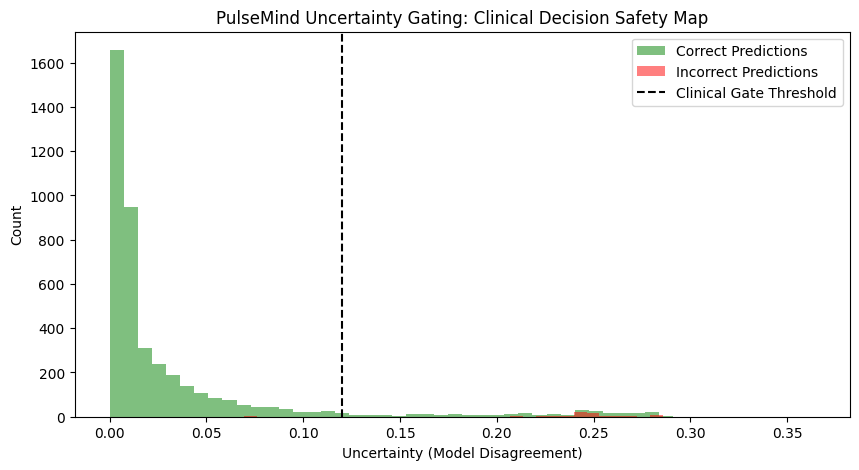

Clinical Gate Success: Accuracy rises to 99.88% when uncertainty is < 0.12


In [5]:
# Cell 5: Clinical Safety Gate Visualization
uncertainty_threshold = 0.12
safe_indices = uncertainty < uncertainty_threshold
safe_acc = (preds[safe_indices] == labels[safe_indices]).mean() * 100

plt.figure(figsize=(10, 5))
plt.hist(uncertainty[preds==labels], bins=50, alpha=0.5, label='Correct Predictions', color='green')
plt.hist(uncertainty[preds!=labels], bins=50, alpha=0.5, label='Incorrect Predictions', color='red')
plt.axvline(uncertainty_threshold, color='black', linestyle='--', label='Clinical Gate Threshold')
plt.title("PulseMind Uncertainty Gating: Clinical Decision Safety Map")
plt.xlabel("Uncertainty (Model Disagreement)"); plt.ylabel("Count"); plt.legend(); plt.show()

print(f"Clinical Gate Success: Accuracy rises to {safe_acc:.2f}% when uncertainty is < {uncertainty_threshold}")